In [110]:
import os
import sys

import plotly.graph_objects as go

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *

from joblib import load



In [111]:
temp_feature = "temperature"
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')

In [112]:
len(df.columns)

29

In [113]:
len(df)

1157892

In [3]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)
df_factors["Date"] = pd.to_datetime(df_factors["Date"])

coefs = {}
grouped = df_factors.groupby(['PowerPlantCode', 'PowerPlantName', "UnitCode"])

for (pp_code, pp_name, unit_code), g in grouped:
    latest_row = g.sort_values("Date", ascending=False).iloc[0]

    coefs[(pp_name, unit_code)] = (latest_row["a1IndexGas"], latest_row["b1IndexGas"])

In [4]:
color_map = {
    1: "purple",
    2: "orange",
    3: "pink",
    4: "blue",
    5: "black",
    6: "red",
    7: "green",
    8: "gray",
    9: "brown"
}

In [5]:
def _add_model_prediction(
        fig,
        df,
        x_col,
        name,
        code,
        project_root,
        model_subdir,
        trace_name,
        dash="solid",
        width=2
):
    try:
        folder_path = os.path.join(project_root, "src", "models", "fitted_models")
        model_path = f"{folder_path}/{model_subdir}/{name}_{code}.joblib"
        model = load(model_path)

        if model_subdir in ["normal6", "normal7"]:
            trace_name = f"smart{model.th:0.2f}"

        x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
        df_line = pd.DataFrame(x_line, columns=[x_col])
        y_line = model.predict(df_line)

        fig.add_trace(go.Scatter(
            x=df_line[x_col],
            y=y_line,
            mode="lines",
            name=trace_name,
            line=dict(dash=dash, width=width),
            visible="legendonly"
        ))
    except Exception as e:
        print(name, code)
        print(e)



In [123]:
def show(df, x_col, y_col, coefs, name, code, color_map, save=False, project_root=None):
    fig = go.Figure()

    # scatter points
    for peak_value, color in color_map.items():
        df_subset = df[df["is_good_peak"] == peak_value]
        fig.add_trace(go.Scatter(
            x=df_subset[x_col],
            y=df_subset[y_col],
            mode="markers",
            marker=dict(size=4, color=color),
            name=f"is_good_peak = {peak_value}",
            hovertext=df_subset["datetime"]
        ))

    fig.update_traces(marker=dict(size=4, sizemode="diameter", sizeref=1, opacity=0.7))

    # linear fit
    a, b = coefs.get((name, code))
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    y_line = a * x_line + b

    fig.add_trace(go.Scatter(
        x=x_line,
        y=y_line,
        mode="lines",
        name=f"y = {a:.3f}x + {b:.3f}",
        line=dict(dash="dash", width=2)
    ))

    # normal models
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal", "predict")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal2", "predict20")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal3", "predict_quantile_95")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal4", "predict_2_line")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal5", "predict_2_line_quantile")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal6", "predict_2_smart_quantile")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal7", "predict_new_smart_quantile")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal8", "predict_2_new_line_quantile")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal9", "predict_quantile_85")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal10", "predict_2_Sep_line_quantile")
    _add_model_prediction(fig, df, x_col, name, code, project_root, "normal11", "predict_final_smart")

    # turbo model
    _add_model_prediction(fig, df, x_col, name, code, project_root, "turbo", "turbo predict")

    if save and project_root:
        save_path = f"{project_root}/src/visualization/unit_figs/test_models/{name}-{code}_s.html"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.write_html(save_path)
    else:
        fig.show()


In [125]:
power_plants = df[['name', 'code']].drop_duplicates()

for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=2))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    try:
        show(df_n_c_plot, temp_feature, "generation", coefs, name_plot, code_plot, color_map, save=True,
             project_root=project_root)
    except Exception as e:
        print(e)
        print(name_plot, code_plot, len(df_n_c_plot))

جنوب اصفهان - چهلستون G11
[Errno 2] No such file or directory: 'U:\\ML_project\\Bargh_ML\\src\\models\\fitted_models/turbo/جنوب اصفهان - چهلستون_G11.joblib'
جنوب اصفهان - چهلستون G12
[Errno 2] No such file or directory: 'U:\\ML_project\\Bargh_ML\\src\\models\\fitted_models/turbo/جنوب اصفهان - چهلستون_G12.joblib'
جنوب اصفهان - چهلستون G13
[Errno 2] No such file or directory: 'U:\\ML_project\\Bargh_ML\\src\\models\\fitted_models/turbo/جنوب اصفهان - چهلستون_G13.joblib'
جنوب اصفهان - چهلستون G14
[Errno 2] No such file or directory: 'U:\\ML_project\\Bargh_ML\\src\\models\\fitted_models/turbo/جنوب اصفهان - چهلستون_G14.joblib'
جنوب اصفهان - چهلستون G15
[Errno 2] No such file or directory: 'U:\\ML_project\\Bargh_ML\\src\\models\\fitted_models/turbo/جنوب اصفهان - چهلستون_G15.joblib'
جنوب اصفهان - چهلستون G16
[Errno 2] No such file or directory: 'U:\\ML_project\\Bargh_ML\\src\\models\\fitted_models/turbo/جنوب اصفهان - چهلستون_G16.joblib'
حافظ G11
[Errno 2] No such file or directory: 'U:\\ML_proj

In [19]:
from src.models.utils import *


def train_and_test_model(X, y, is_turbo, name, code):
    X_train, X_test, y_train, y_test = split_X_and_y(X, y, test_size=0.01, shuffle=False)

    folder_path = os.path.join(project_root, "src", "models", "fitted_models")
    model_path = f"{folder_path}/{'turbo' if is_turbo else 'normal'}/{name}_{code}.joblib"
    model = load(model_path)

    y_pred_train = model.predict(X_train)
    rmse_error_train = compute_relative_rmse(y_pred_train, y_train)

    y_pred_test = model.predict(X_test)
    rmse_error_test = compute_relative_rmse(y_pred_test, y_test)
    return rmse_error_train, rmse_error_test, y_pred_train - y_train, y_pred_test - y_test

In [114]:
from src.models.filter_data.filter_data import turbo_dict
import pandas as pd

rows = []
for row in power_plants.itertuples():
    name, code = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=6))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    if not turbo_dict[name][code]:
        continue
    try:
        folder_path = os.path.join(project_root, "src", "models", "fitted_models")
        model_path = f"{folder_path}/{'normal10'}/{name}_{code}.joblib"
        model = load(model_path)
        s1 = model.info["slopes"][0]
        s2 = model.info["slopes"][1]
        xp = model.info["inter_point"][0]
        x1 = model.breakpoints[0]
        x2 = model.breakpoints[2]
        dx = x2 - x1
        z2 = int(len(df_n_c_plot[df_n_c_plot[temp_feature]>model.breakpoints[1]])/len(df_n_c_plot)*100)
        rows.append({
            "name": name,
            "code": code,
            "ds": abs(s1 - s2),
            "c0": (0 > s1 > s2),
            "c1": abs(s1 - s2) >= 0.25,
            "c2": abs(s1 - s2) < 2.5,
            "c3": (x1 < xp < x2),
            "cc": (0 > s1 > s2) and (x1 < xp < x2) and 2.5 > abs(s1 - s2) >= 0.25 and z2>5,
            "z1" : x2-xp,
            "z2" : z2>5,
            "s1": s1,
            "s2": s2,
            "int_point": model.info["inter_point"],
            "breakpoints": model.breakpoints,
        })
    except Exception as e:
        print(name, code,e)

# ساخت DataFrame نهایی
results_df = pd.DataFrame(rows)


In [118]:
vr = results_df[results_df["cc"]]
vr


,name,code,ds,c0,c1,c2,c3,cc,z1,z2,s1,s2,int_point,breakpoints
3,سیکل ترکیبی شیروان,G14,0.293305,True,True,True,True,True,10.250867,True,-0.635409,-0.928714,"(26.480132895218357, 123.19581630775525)","[0.331, 29.831000992869996, 36.731]"
12,شهدای پاکدشت - دماوند,G14,1.109533,True,True,True,True,True,4.820609,True,-0.806400,-1.915934,"(37.159890702433465, 117.27744484361921)","[6.3304996, 36.893301607722314, 41.9805]"
13,شهدای پاکدشت - دماوند,G15,0.875132,True,True,True,True,True,5.901688,True,-0.760474,-1.635606,"(36.078812327033326, 117.85902131346677)","[8.0805, 35.8257976404469, 41.9805]"
17,شهدای پاکدشت - دماوند,G19,0.331803,True,True,True,True,True,9.818020,True,-0.725476,-1.057279,"(32.1624802838949, 118.48768520855384)","[3.1305, 33.18508250029807, 41.9805]"
19,شهدای پاکدشت - دماوند,G21,0.256767,True,True,True,True,True,10.465258,True,-0.741099,-0.997867,"(31.115242435412803, 121.29291968178275)","[3.0805001, 30.167901364643896, 41.5805]"
20,شهدای پاکدشت - دماوند,G22,0.464699,True,True,True,True,True,3.824544,True,-0.775853,-1.240553,"(34.25595629851558, 121.849962312609)","[28.080502, 33.68049998036325, 38.0805]"


(array([1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 2., 1., 0., 1., 0., 2.,
        1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1.,
        2., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
        0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.2606602 , 0.27300535, 0.2853505 , 0.29769565, 0.3100408 ,
        0.32238595, 0.33473109, 0.34707624, 0.35942139, 0.37176654,
        0.38411169, 0.39645684, 0.40880199, 0.42114713, 0.43349228,
        0.44583743, 0.45818258, 0.47052773, 0.48287288, 0.49521803,
        0.50756317, 0.51990832, 0.53225347, 0.54459862, 0.55694377,
        0.56928892, 0.58163407, 0.59397921, 0.60632436, 0.61866951,
        0.63101466, 0.64335981, 0.65570496, 0.66805011, 0.68039526,
        0.6927404 , 0.70508555, 0.7174307 , 0.72977585, 0.742121  ,
      

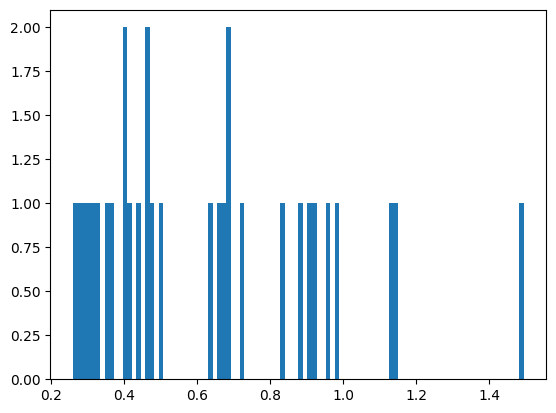

In [92]:
import matplotlib.pyplot as plt

plt.hist(vr["ds"], bins=100)

In [179]:
from src.models.data_selection.feature_selector import Feature_selector
import pandas as pd

rows = []
rd = {}
for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code

    # train/test برای حالت عادی

    try:
        ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=6, is_tight=True))
        df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
        n_samples_normal = len(df_n_c_plot)
        fs_n_c = Feature_selector(df_n_c_plot, "generation")
        fs_n_c.filter_features(features_to_select=["temperature"])
        X, y = fs_n_c.get_X_and_y()
        train_error_normal, test_error_normal, yr1, yr2 = train_and_test_model(X, y, False, name_plot, code_plot)
        rd[(name_plot, code_plot)] = yr1
    except Exception as e:
        train_error_turbo, test_error_turbo = None, None  # اگر مدل توربو خراب شد
        print(e)
    # train/test برای حالت توربو
    try:
        ds_n_c_plot = Data_selector(Data_selector(df).select_peaks(goodness=7, is_tight=True))
        df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
        n_samples_turbo = len(df_n_c_plot)
        fs_n_c = Feature_selector(df_n_c_plot, "generation")
        fs_n_c.filter_features(features_to_select=["temperature"])
        X, y = fs_n_c.get_X_and_y()
        train_error_turbo, test_error_turbo, yr1, yr2 = train_and_test_model(X, y, True, name_plot, code_plot)
    except:
        train_error_turbo, test_error_turbo = None, None  # اگر مدل توربو خراب شد

    rows.append({
        "name": name_plot,
        "code": code_plot,
        "n_samples_turbo": n_samples_turbo,
        "n_samples_normal": n_samples_normal,
        "train_error_normal": train_error_normal,
        "test_error_normal": test_error_normal,
        "train_error_turbo": train_error_turbo,
        "test_error_turbo": test_error_turbo
    })

# ساخت DataFrame نهایی
results_df = pd.DataFrame(rows)


With n_samples=0, test_size=0.01 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.


In [180]:
results_df

,name,code,n_samples_turbo,n_samples_normal,train_error_normal,test_error_normal,train_error_turbo,test_error_turbo
0,جنوب اصفهان - چهلستون,G11,0,724,1.887206,2.761447,NaN,NaN
1,جنوب اصفهان - چهلستون,G12,0,454,2.323065,1.534365,NaN,NaN
2,جنوب اصفهان - چهلستون,G13,0,584,2.291937,1.007993,NaN,NaN
3,جنوب اصفهان - چهلستون,G14,0,387,2.250483,1.929672,NaN,NaN
4,جنوب اصفهان - چهلستون,G15,0,435,1.850431,1.254274,NaN,NaN
...,...,...,...,...,...,...,...,...
67,گیلان,G12,0,498,1.369188,0.945136,NaN,NaN
68,گیلان,G13,0,453,1.490057,1.204135,NaN,NaN
69,گیلان,G14,0,377,1.897495,0.860454,NaN,NaN
70,گیلان,G15,0,229,1.742789,0.576073,NaN,NaN


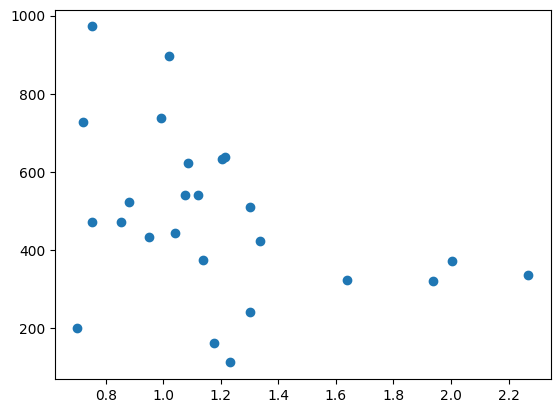

In [146]:
from matplotlib import pyplot as plt

mask = results_df["n_samples_turbo"] != 0
x = results_df[mask]["train_error_normal"]
y = results_df[mask]["n_samples_normal"]
plt.scatter(x, y)

In [150]:
sum(x.values * y.values) / sum(y)

np.float64(1.122133784705433)

In [128]:
results_df.sort_values(by="test_error_normal")

,name,code,n_samples_turbo,n_samples_normal,train_error_normal,test_error_normal,train_error_turbo,test_error_turbo
55,عسلویه,G16,0,388,1.246894,0.229798,NaN,NaN
21,سیکل ترکیبی ارومیه,G14,0,625,1.195404,0.265903,NaN,NaN
43,شهدای پاکدشت - دماوند,G18,487,633,1.205062,0.420118,0.778638,0.875624
62,پرند,G13,0,565,1.163266,0.495859,NaN,NaN
7,حافظ,G12,0,602,1.729902,0.539836,NaN,NaN
...,...,...,...,...,...,...,...,...
66,گیلان,G11,0,960,1.337711,3.121054,NaN,NaN
11,حافظ,G16,0,431,1.544104,3.387612,NaN,NaN
12,سبلان,G11,0,972,0.944642,3.709676,NaN,NaN
30,سیکل ترکیبی یزد,G11,0,507,2.058258,4.245955,NaN,NaN


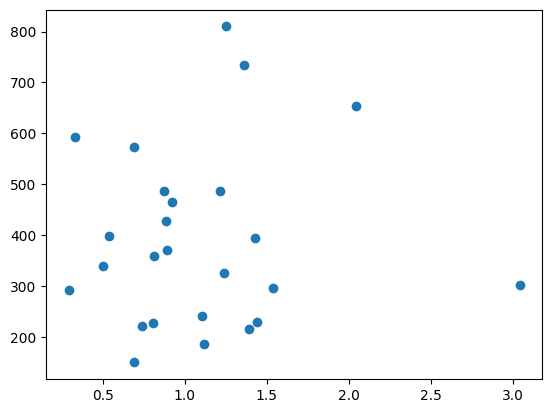

In [143]:
from matplotlib import pyplot as plt

x = results_df["test_error_turbo"]
y = results_df["n_samples_turbo"]
plt.scatter(x, y)

In [139]:
rr = rd[("عسلویه", "G12")]

(array([87., 28., 11., 10., 12.,  2.,  2.,  1.,  2.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         2.]),
 array([2.42865758e-06, 4.87597599e+00, 9.75194955e+00, 1.46279231e+01,
        1.95038967e+01, 2.43798702e+01, 2.92558438e+01, 3.41318174e+01,
        3.90077909e+01, 4.38837645e+01, 4.87597380e+01, 5.36357116e+01,
        5.85116852e+01, 6.33876587e+01, 6.82636323e+01, 7.31396058e+01,
        7.80155794e+01, 8.28915530e+01, 8.77675265e+01, 9.26435001e+01,
        9.75194737e+01, 1.02395447e+02, 1.07271421e+02, 1.12147394e+02,
        1.17023368e+02, 1.21899341e+02, 1.26775315e+02, 1.31651289e+02,
        1.36527262e+02, 1.41403236e+02, 1.46279209e+02, 1.51155183e+02,
        1.56031156e+02, 1.60907130e+02, 1.65783104e+02, 1.70659077e+02,
        1.75535051e+02, 1.80411024e+02, 1.85286998e+02, 1.90162971e+02,
        1.95038945e+02]),
 <BarContainer objec

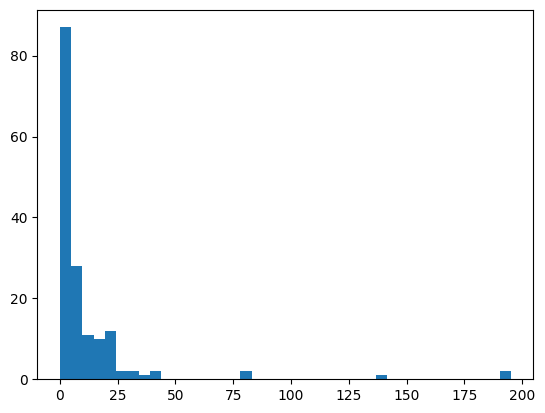

In [142]:
plt.hist(rr * rr, bins=40)

In [168]:
ard = []
for k in rd:
    ard += list(rd[k])
ard = abs(np.array(ard))

In [169]:
ard.sort()

In [170]:
ard

array([1.18513169e-06, 3.86876372e-05, 8.47749293e-05, ...,
       1.61401289e+01, 1.61465814e+01, 1.61885149e+01], shape=(35368,))

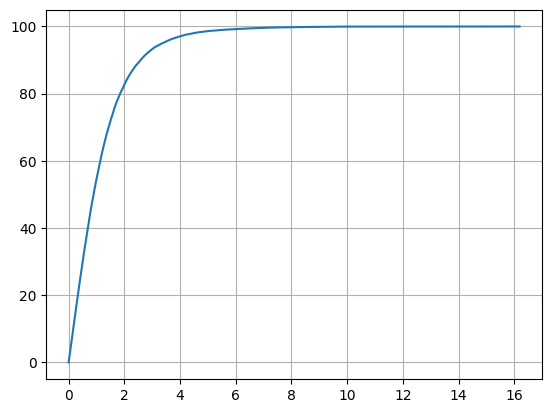

In [172]:
plt.plot(ard, np.arange(len(ard)) / len(ard) * 100)
plt.grid()